# SAM + Retail Rates: Battery Dispatch Showcase

This notebook demonstrates using PySAM to run a PV + Battery model with retail Time-of-Use (TOU) rates and explores how dispatch settings (e.g., minimum SOC, grid charging, retail-price dispatch) affect battery utilization. It pulls retail rates from `helpers/electricity_rate_helpers.py`.

In [1]:
import os, json, math, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure repository root (containing 'helpers/') is on sys.path when running from notebooks/
def _add_repo_root_to_syspath():
    d = os.getcwd()
    for _ in range(5):
        if os.path.isdir(os.path.join(d, 'helpers')):
            if d not in sys.path:
                sys.path.insert(0, d)
            return d
        d = os.path.abspath(os.path.join(d, '..'))
    return None
repo_root = _add_repo_root_to_syspath()
print('Repo root on sys.path:', repo_root)
# Ensure file paths resolve relative to repository root (SAM_configuration uses relative paths)
if repo_root is not None:
    os.chdir(repo_root)

import PySAM.Pvwattsv8 as pvwatts
import PySAM.Battwatts as battw
import PySAM.Battery as Battery
import PySAM.ResourceTools as tools
# Utilityrate5 is shown for completeness; we build a price vector here
import PySAM.Utilityrate5 as UtilityRate

from helpers.electricity_rate_helpers import PGE_RATE_PLANS, SCE_RATE_PLANS, SDGE_RATE_PLANS
from main_helpers import slugify_county_name
from step9_run_sam_model_for_solar_storage import (
    prepare_data_and_compute_system_capacity,
    create_solar_model,
    create_battery_model,
    run_models_and_extract_outputs,
)

pd.options.display.max_columns = 200
plt.rcParams['figure.figsize'] = (12, 4)
print('PySAM ready')

Repo root on sys.path: /Users/ana/Documents/Berkeley/CCAI/cost-of-solar-storage
PySAM ready


## Build Retail Rate Vector (8760)

We construct an hourly price vector from the repository's retail rate definitions. Below, we use PG&E `E-TOU-D` as an example. Adjust months and weekend rules as needed.

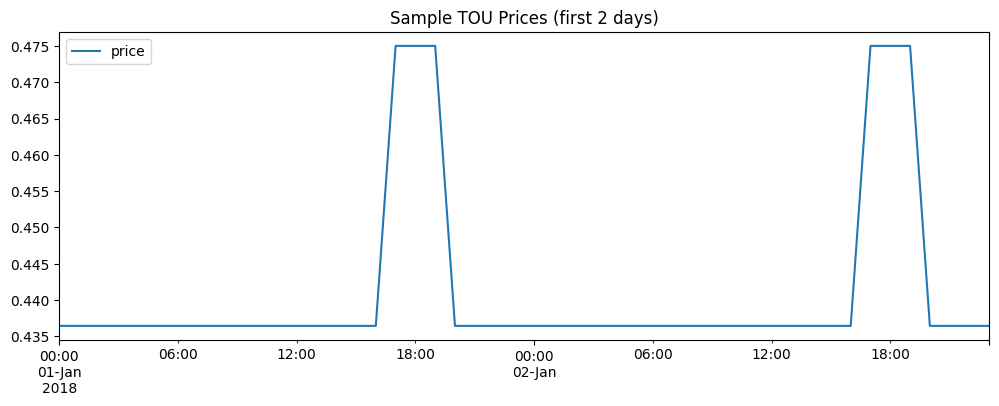

(0.44044264041095904, 0.56462)

In [2]:
from datetime import datetime

def is_summer(dt):
    # Jun-Sep
    return dt.month in (6, 7, 8, 9)

def build_hourly_prices(year=2018, utility='PGE', plan='E-TOU-D'):
    if utility == 'PGE':
        plan_def = PGE_RATE_PLANS[plan]
    elif utility == 'SCE':
        plan_def = SCE_RATE_PLANS[plan]
    elif utility == 'SDGE':
        plan_def = SDGE_RATE_PLANS[plan]
    else:
        raise ValueError('Unknown utility')

    idx = pd.date_range(start=f'{year}-01-01', end=f'{year}-12-31 23:00:00', freq='H')
    prices = []
    for t in idx:
        season_key = 'summer' if is_summer(t) else 'winter'
        is_weekend = t.weekday() >= 5
        day_key = 'weekends' if is_weekend else 'weekdays'
        sdef = plan_def[season_key][day_key]
        hr = t.hour
        if 'partPeakHours' in sdef and hr in sdef['partPeakHours']:
            price = sdef.get('partPeak', sdef.get('offPeak'))
        elif 'superOffPeakHours' in sdef and hr in sdef['superOffPeakHours']:
            price = sdef.get('superOffPeak', sdef.get('offPeak'))
        elif hr in sdef.get('peakHours', []):
            price = sdef['peak']
        else:
            price = sdef['offPeak']
        prices.append(price)
    return idx, np.array(prices)

idx, price_vec = build_hourly_prices(2018, 'PGE', 'E-TOU-D')
pd.DataFrame({'price': price_vec}, index=idx).iloc[:48].plot(title='Sample TOU Prices (first 2 days)'); plt.show()
price_vec.mean(), price_vec.max()

## Select Scenario Inputs

Point to an existing weather file and a combined load profile for a county within `data/loadprofiles/`. If these files are not present locally, adjust to a county you have, or generate inputs first via the pipeline (steps 7–9).

In [3]:
scenario = 'baseline'
housing = 'single-family-detached'
county_name = 'Alameda County'  # human-readable
county = slugify_county_name(county_name)  # slug used in paths/files
# Use absolute path anchored at repo root so paths work when running from notebooks/
base = os.path.join(os.getcwd(), 'data', 'loadprofiles')

weather_file = os.path.join(base, scenario, housing, county, f'weather_TMY_{county}.csv')
load_file = os.path.join(base, scenario, housing, county, f'combined_profiles_{scenario}_{county}.csv')
weather_file, load_file, os.path.exists(weather_file), os.path.exists(load_file)

('/Users/ana/Documents/Berkeley/CCAI/cost-of-solar-storage/data/loadprofiles/baseline/single-family-detached/alameda/weather_TMY_alameda.csv',
 '/Users/ana/Documents/Berkeley/CCAI/cost-of-solar-storage/data/loadprofiles/baseline/single-family-detached/alameda/combined_profiles_baseline_alameda.csv',
 True,
 True)

## Build Models and Adjust Dispatch Settings

We: (1) compute a reasonable PV system size for the selected load and location, (2) create PVWatts + Battery models, and (3) adjust battery dispatch settings.

Key changes for improved utilization:
- Lower minimum SOC (e.g., from 0.30 to 0.05–0.10).
- Allow grid charging when retail-price arbitrage makes sense.
- Use retail-price-based dispatch (choice=4) to respond to TOU prices.

In [6]:
years = 1
solar_resource_data, load_profile, system_kw = prepare_data_and_compute_system_capacity(weather_file, load_file, years)
solar = create_solar_model(solar_resource_data, system_kw, years)
battery = Battery.from_existing(solar)
battery.Load.load = load_profile

# Dispatch config
battery.BatteryCell.batt_minimum_SOC = 10  # percent (0-100)
battery.BatteryDispatch.batt_dispatch_choice = 4  # RetailRateDispatch
battery.BatteryDispatch.batt_dispatch_auto_can_gridcharge = 1
battery.BatteryDispatch.batt_dispatch_auto_btm_can_discharge_to_grid = 0
battery.Lifetime.analysis_period = years

# Simple TOU schedule derived from hourly prices (2 periods: off-peak=1, peak=2)
battery.ElectricityRates.ur_enable_net_metering = 0
peak_threshold = float(price_vec.max()) * 0.95
tou_periods = [2 if float(p) >= peak_threshold else 1 for p in price_vec.tolist()]
battery.ElectricityRates.ur_tou_sched_weekday = tou_periods
battery.ElectricityRates.ur_tou_sched_weekend = tou_periods
# Average rates per period for the TOU matrix
off_vals = [float(p) for p in price_vec if float(p) < peak_threshold]
peak_vals = [float(p) for p in price_vec if float(p) >= peak_threshold]
off_rate = float(np.mean(off_vals)) if off_vals else float(price_vec.mean())
peak_rate = float(np.mean(peak_vals)) if peak_vals else float(price_vec.max())
battery.ElectricityRates.ur_tou_mat = [
    [1, 1, off_rate, 0.0],
    [1, 2, peak_rate, 0.0],
]

print('Battery min SOC (%):', getattr(battery.BatteryCell, 'batt_minimum_SOC'))

AttributeError: 'Battwatts' object has no attribute 'BatteryCell'

## Execute and Inspect Battery Utilization

We run the models, plot SOC, and check whether utilization improves beyond a 60% floor.

In [ ]:
# Quick introspection to confirm available ElectricityRates fields before execute
print('Available ElectricityRates fields (subset):')
print([k for k in dir(battery.ElectricityRates) if k.startswith('ur_') or k.startswith('en_')][:40])


In [ ]:
system_to_load, batt_to_load, grid_to_load, solar_batt_to_load, total_supply, diff, grid_to_batt, system_to_batt, system_to_batt_dc, system_to_grid, load, soc, pv_kw, batt_kwh = run_models_and_extract_outputs(solar, battery, load_profile)
print({'pv_kw': pv_kw, 'batt_kwh': batt_kwh})
dt_index = pd.date_range('2018-01-01', periods=8760, freq='H')
df = pd.DataFrame({
    'Load': load_profile,
    'SOC': soc,
    'Batt->Load': batt_to_load,
    'Grid->Batt': grid_to_batt,
    'Sys->Batt': system_to_batt,
    'Grid->Load': grid_to_load,
    'Sys->Grid': system_to_grid,
}, index=dt_index)
ax = df['SOC'].plot(title='Battery State of Charge (%)'); ax.set_ylim(0, 100); plt.show()
df[['Batt->Load','Grid->Batt','Sys->Batt']].iloc[:168].plot(title='Battery Flows (first week)'); plt.show()
print('SOC min/max:', float(df['SOC'].min()), float(df['SOC'].max()))

## Simple Bill Comparison Using Retail Prices

This computes an approximate energy bill using the hourly TOU price vector. It treats exports at $0 for simplicity; refine as needed (e.g., use export credits or NEM rules).

In [ ]:
# Build price vector (already created above)
prices = price_vec

# Net grid import (kW) each hour
net_grid = np.array(grid_to_load) + np.array(grid_to_batt) - np.array(system_to_grid)
imports = np.clip(net_grid, 0, None)
exports = np.clip(-net_grid, 0, None)
bill_energy_only = float((imports * prices).sum())
export_credit = 0.0  # customize if credits apply
net_bill = bill_energy_only - export_credit
print({'imports_kwh': float(imports.sum()), 'exports_kwh': float(exports.sum()), 'bill_energy_only_$': bill_energy_only, 'net_bill_$': net_bill})

## Notes
- If SOC remains bounded above ~60%, the battery minimum SOC is likely still at 30%. Lower it as shown above.
- For full tariff fidelity (tiers, baseline credit, demand charges), program `Utilityrate5` schedules and matrices or reuse `SAM_configuration/untitled__1__utilityrate5.json` and adjust.
- To test rate sensitivity, swap to SCE or SDG&E plans by changing `utility`/`plan` in `build_hourly_prices`.